# **SpaceX Falcon 9 First Stage Landing Prediction**


## Project Overview


SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars, while other providers charge upwards of 165 million dollars per launch. Much of SpaceX's cost advantage comes from their ability to reuse the first stage of the rocket. By analyzing launch data and predicting whether the first stage will successfully land, we can estimate launch costs more accurately. This information would be valuable for competing aerospace companies when bidding against SpaceX for launch contracts or for investors analyzing the space launch market.

## Project Goals


This project aims to:

1. Perform exploratory data analysis on SpaceX launch data
2. Create a binary classification target variable for first stage landing success
3. Standardize the data and split into training/test sets
4. Develop and tune classification models (Logistic Regression, SVM, Decision Trees, KNN)
5. Compare model performance and identify the best model for predicting landing success

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%cd "/content/drive/Othercomputers/My MacBook Pro/portfolio/spacex"
file_prefix = %pwd

/content/drive/Othercomputers/My MacBook Pro/portfolio/spacex


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score

In [4]:
# define a helper function to plot the confusion matrix
def plot_confusion_matrix(y, y_hat):
  cm = confusion_matrix(y, y_hat)
  ax = plt.subplot()
  sns.heatmap(cm, annot = True, ax = ax)
  ax.set_xlabel("predicted labels")
  ax.set_ylabel("true labels")
  ax.set_title("Confusion Matrix")
  ax.xaxis.set_ticklabels(["did not land", "landed"])
  ax.yaxis.set_ticklabels(["did not land", "landed"])
  plt.show()

In [5]:
# load the SpaceX flight record data including Class
# Class = 1 indicates landing success;
# Class = 0 indicates landing failure
# Class is our categorical target variable
y = pd.read_csv("data/spacex_flight_records_class.csv")
y = y["Class"].to_numpy()

In [6]:
frac_successful = np.sum(y)/len(y)
print("{} percent of stage one landings were successful.".format(frac_successful*100))

66.66666666666666 percent of stage one landings were successful.


The data shows approximately 2/3 of stage one landings were successful and 1/3 unsuccessful. This relatively balanced distribution is advantageous for modeling without requiring special handling for class imbalance.

In [7]:
# load additional flight record data for corresponding flights
Xdata = pd.read_csv("data/spacex_flight_records.csv")
Xdata.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [8]:
predictive_features = Xdata.columns.values
predictive_features = [x for x in predictive_features if x != "FlightNumber"]
X = Xdata[predictive_features]
print(predictive_features)
print(X.shape)

['PayloadMass', 'Flights', 'Block', 'ReusedCount', 'Orbit_ES-L1', 'Orbit_GEO', 'Orbit_GTO', 'Orbit_HEO', 'Orbit_ISS', 'Orbit_LEO', 'Orbit_MEO', 'Orbit_PO', 'Orbit_SO', 'Orbit_SSO', 'Orbit_VLEO', 'LaunchSite_CCAFS SLC 40', 'LaunchSite_KSC LC 39A', 'LaunchSite_VAFB SLC 4E', 'LandingPad_5e9e3032383ecb267a34e7c7', 'LandingPad_5e9e3032383ecb554034e7c9', 'LandingPad_5e9e3032383ecb6bb234e7ca', 'LandingPad_5e9e3032383ecb761634e7cb', 'LandingPad_5e9e3033383ecbb9e534e7cc', 'Serial_B0003', 'Serial_B0005', 'Serial_B0007', 'Serial_B1003', 'Serial_B1004', 'Serial_B1005', 'Serial_B1006', 'Serial_B1007', 'Serial_B1008', 'Serial_B1010', 'Serial_B1011', 'Serial_B1012', 'Serial_B1013', 'Serial_B1015', 'Serial_B1016', 'Serial_B1017', 'Serial_B1018', 'Serial_B1019', 'Serial_B1020', 'Serial_B1021', 'Serial_B1022', 'Serial_B1023', 'Serial_B1025', 'Serial_B1026', 'Serial_B1028', 'Serial_B1029', 'Serial_B1030', 'Serial_B1031', 'Serial_B1032', 'Serial_B1034', 'Serial_B1035', 'Serial_B1036', 'Serial_B1037', 'Ser

In [9]:
# standardize the X data using standard scaling
transform = StandardScaler()
X = transform.fit_transform(X)

In [10]:
# split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 5)

## Logistic Regression Model

We use grid search to optimize the logistic regression hyperparameters: regularization parameter C, penalty type, and solver algorithm.

In [11]:
# set dictionary of parameters to perform GridSearchCV
# note that lbfgs is only compatible with L2 regularization
# (or no regularization) -- will throw warning
parameters = {"C":        np.logspace(-2,+2,20),
              "penalty":  ["l1", "l2", None],
              "solver":   ["liblinear", "lbfgs", "saga"]}

In [12]:
logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg,
                         parameters,
                         cv = 10,
                         n_jobs = -1).fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
400 fits failed out of a total of 1800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_so

In [13]:
# print tuned hyperparameters, train and test accuracy
print("tuned hyperparameters: ", logreg_cv.best_params_)
print("training accuracy: ", logreg_cv.best_score_)
logreg_testing_accuracy = logreg_cv.score(X_test, y_test)
print("testing accuracy: ", logreg_testing_accuracy)
y_hat_logreg = logreg_cv.predict(X_test)
logreg_testing_f1 = f1_score(y_test, y_hat_logreg)
print("testing F1 score: ", logreg_testing_f1)

tuned hyperparameters:  {'C': np.float64(0.026366508987303583), 'penalty': 'l2', 'solver': 'lbfgs'}
training accuracy:  0.8571428571428573
testing accuracy:  0.8148148148148148
testing F1 score:  0.8837209302325582


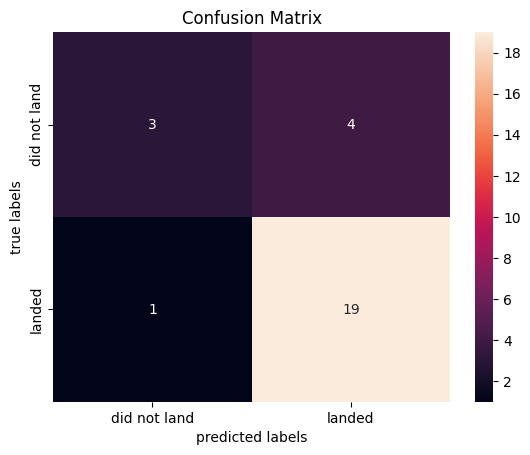

In [14]:
# plot confusion matrix based on test data predictions
plot_confusion_matrix(y_test, y_hat_logreg)

The main issue with this model appears to be false positives - cases where the model predicted a successful landing but the stage actually failed to land. This type of error could lead to underestimating launch costs.

## Support Vector Classifier

Next, I'll optimize an SVM classifier by tuning the kernel function, regularization parameter C, and kernel bandwidth gamma.

In [15]:
parameters = {"kernel": ["linear", "rbf", "poly", "sigmoid"],
              "C":      np.logspace(-3, +3, 10),
              "gamma":  np.logspace(-3, +3, 10)}

In [16]:
svc = SVC()
svc_cv = GridSearchCV(svc,
                      parameters,
                      cv = 10,
                      n_jobs = -1).fit(X_train, y_train)

In [17]:
# print tuned hyperparameters, train and test accuracy
print("tuned hyperparameters: ", svc_cv.best_params_)
print("training accuracy: ", svc_cv.best_score_)
svc_testing_accuracy = svc_cv.score(X_test, y_test)
print("testing accuracy: ", svc_testing_accuracy)
y_hat_svc = svc_cv.predict(X_test)
svc_testing_f1 = f1_score(y_test, y_hat_svc)
print("testing F1 score: ", svc_testing_f1)

tuned hyperparameters:  {'C': np.float64(2.154434690031882), 'gamma': np.float64(0.1), 'kernel': 'sigmoid'}
training accuracy:  0.8880952380952379
testing accuracy:  0.7777777777777778
testing F1 score:  0.85


The SVM model performs slightly worse on the test data than the logistic regression model, suggesting the decision boundary may be more linear than nonlinear.

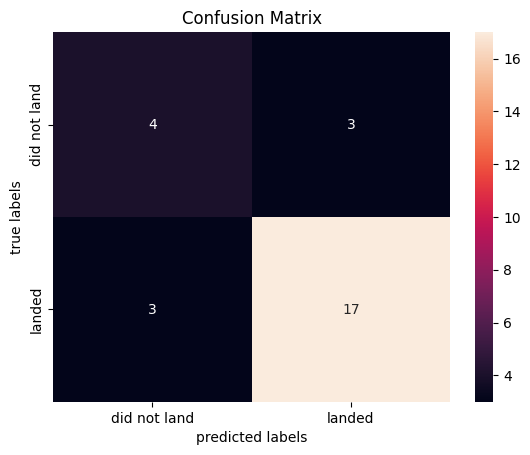

In [18]:
# plot confusion matrix based on test data predictions
plot_confusion_matrix(y_test, y_hat_svc)

The SVM model produces three false positives and false negatives. It shows no bias, but its performs worse overall.

## Decision Tree Classifier

Next, I'll implement a decision tree classifier and optimize its hyperparameters. Decision trees offer the advantage of being highly interpretable and can capture nonlinear relationships in the data. Key parameters to tune include:

In [19]:
parameters = {"criterion":          ["gini", "entropy"],
              "splitter":           ["best", "random"],
              "max_depth":          [2*n for n in range(1,11)],
              "min_samples_split":  [2, 5, 10],
              "min_samples_leaf":   [1, 2, 4],
              "max_features":       [None, "sqrt", "log2"]}

This grid search explores various options for split criteria, tree depth, minimum samples required for splitting, and feature selection methods. Using cross-validation helps prevent overfitting, a common issue with decision trees.

In [20]:
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree,
                       parameters,
                       cv = 10,
                       n_jobs = -1).fit(X_train, y_train)

In [21]:
# print tuned hyperparameters, train and test accuracy
print("tuned hyperparameters: ", tree_cv.best_params_)
print("training accuracy: ", tree_cv.best_score_)
tree_testing_accuracy = tree_cv.score(X_test, y_test)
print("testing accuracy: ", tree_testing_accuracy)
y_hat_tree = tree_cv.predict(X_test)
tree_testing_f1 = f1_score(y_test, y_hat_tree)
print("testing F1 score: ", tree_testing_f1)

tuned hyperparameters:  {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
training accuracy:  0.9190476190476191
testing accuracy:  0.7407407407407407
testing F1 score:  0.8


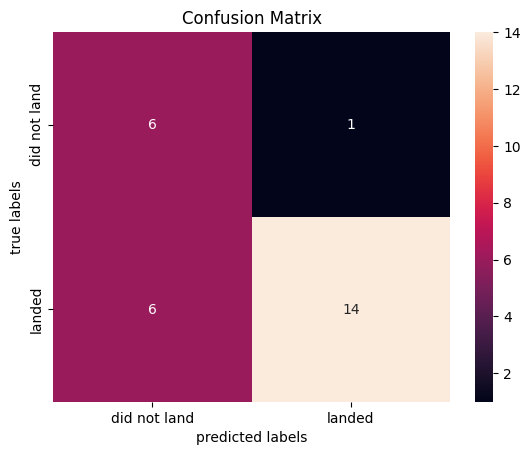

In [22]:
# plot confusion matrix based on test data predictions
plot_confusion_matrix(y_test, y_hat_tree)

Despite having the highest training accuracy, the decision tree model performs worse on the test set. This suggests the model is overfitting to the training data, capturing noise rather than generalizable patterns. Decision trees are known for this tendency, which is why ensemble methods like random forests are often preferred in practice.

Additionally, the model shows a significant bias, with six false negatives and only a single false positive. This could lead to the overestimation of launch costs.

## K-Nearest Neighbors

Finally, I'll implement a K-Nearest Neighbors classifier, which makes predictions based on proximity to training examples in feature space.

In [23]:
parameters = {"n_neighbors":  np.arange(1,11),
              "algorithm":    ["auto", "ball_tree", "kd_tree", "brute"],
              "p":            [1, 2]}

I'll tune the number of neighbors (from 1-10), the algorithm used to compute distances, and the distance metric (Manhattan or Euclidean).

In [24]:
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn,
                      parameters,
                      cv = 10,
                      n_jobs = -1).fit(X_train, y_train)

In [25]:
# print tuned hyperparameters, train and test accuracy
print("tuned hyperparameters: ", knn_cv.best_params_)
print("training accuracy: ", knn_cv.best_score_)
knn_testing_accuracy = knn_cv.score(X_test, y_test)
print("testing accuracy: ", knn_testing_accuracy)
y_hat_knn = knn_cv.predict(X_test)
knn_testing_f1 = f1_score(y_test, y_hat_knn)
print("testing F1 score: ", knn_testing_f1)

tuned hyperparameters:  {'algorithm': 'auto', 'n_neighbors': np.int64(4), 'p': 1}
training accuracy:  0.8714285714285716
testing accuracy:  0.8518518518518519
testing F1 score:  0.9


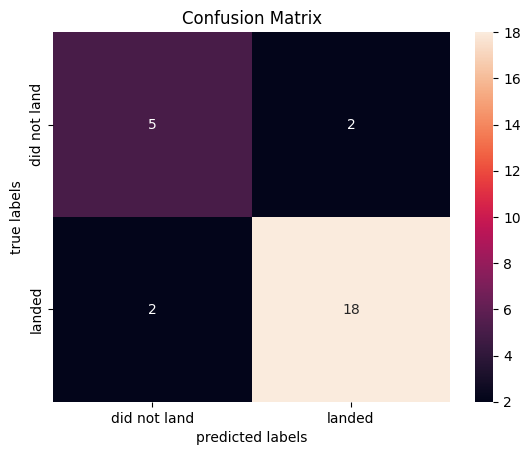

In [26]:
# plot confusion matrix based on test data predictions
plot_confusion_matrix(y_test, y_hat_knn)

This model performs better on the test data than logistic regression and is unbiased.

## Model Comparison and Conclusion

Now I'll compare all four models to identify the best performer for predicting SpaceX first stage landing success.

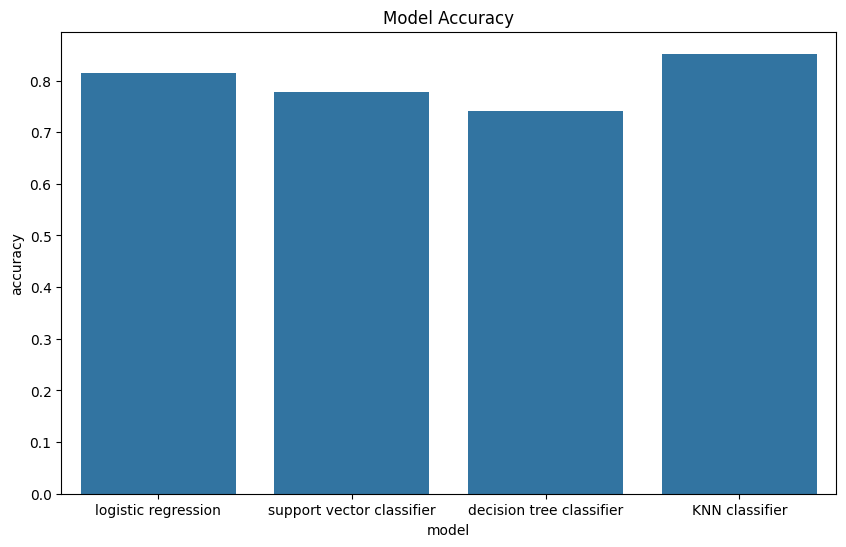

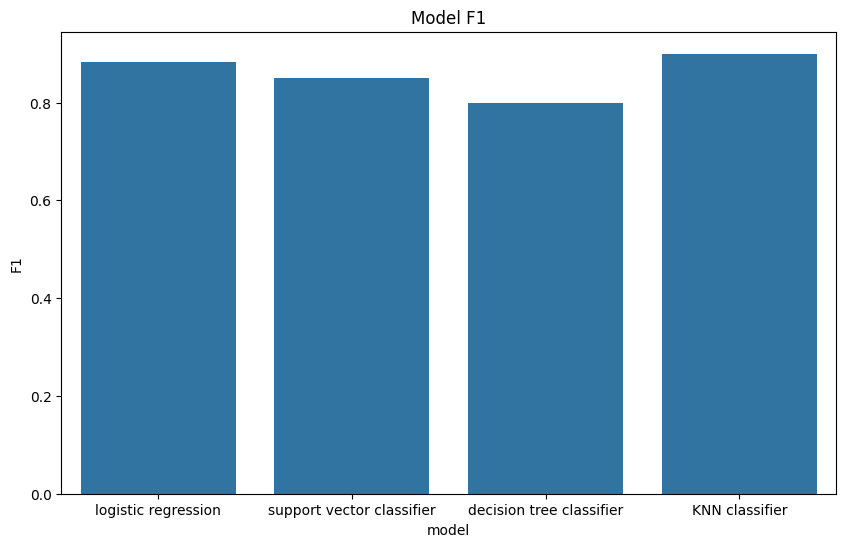

In [27]:
# plot testing accuracy of each model
accuracy_df = pd.DataFrame(
                {"model":     ["logistic regression",
                               "support vector classifier",
                               "decision tree classifier",
                               "KNN classifier"],
                 "accuracy":  [logreg_testing_accuracy,
                               svc_testing_accuracy,
                               tree_testing_accuracy,
                               knn_testing_accuracy],
                 "F1":        [logreg_testing_f1,
                               svc_testing_f1,
                               tree_testing_f1,
                               knn_testing_f1]})

fig = plt.subplots(figsize = (10,6))
sns.barplot(x = "model", y = "accuracy", data = accuracy_df)
plt.title("Model Accuracy")
plt.show()

fig = plt.subplots(figsize = (10,6))
sns.barplot(x = "model", y = "F1", data = accuracy_df)
plt.title("Model F1")
plt.show()

Based on both accuracy and F1 score metrics, the KNN model performs best on unseen data.

The logistic regression model shows signs of bias, producing more false positives than false negatives. While unbiased, the SVM shows signs of overfitting. The decision tree classifier is the worst of the models examined here, exhibiting a significant bias and the lowest test set accuracy of all the models.

For future work, ensemble methods like random forests or gradient boosting might be worth exploring to potentially improve predictive performance while maintaining good generalization.